In [2]:
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_squared_error, r2_score

import matplotlib.pyplot as plt

import seaborn as sns
import numpy as np



df=pd.read_csv('StudentPerformanceFactors.csv')

df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [3]:
df.isnull().sum()


Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [4]:
df.dropna(axis =1 , inplace=True)

df.isnull().sum()

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Gender                        0
Exam_Score                    0
dtype: int64

In [5]:
df.drop_duplicates(inplace=True)

df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Public,Positive,3,No,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Public,Negative,4,No,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Public,Neutral,4,No,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Public,Negative,4,No,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,Public,Neutral,4,No,Female,70


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  School_Type                 6607 non-null   str  
 12  Peer_Influence              6607 non-null   str  
 13  Physical_Activity           6607 non-null   int64
 14  Learning_Disabiliti

In [7]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [8]:
categorical_columns = df.select_dtypes(include="str").columns.tolist()

print("Categorical columns:")
print(categorical_columns)

numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
numerical_columns = [
    column for column in numerical_columns
    if column != "Exam_Score"
]

print("Numerical columns:")
print(numerical_columns)

print("\nCategorical columns:")
print(categorical_columns)
for column in categorical_columns:

    print(df[column].value_counts())

Categorical columns:
['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Gender']
Numerical columns:
['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']

Categorical columns:
['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Gender']
Parental_Involvement
Medium    3362
High      1908
Low       1337
Name: count, dtype: int64
Access_to_Resources
Medium    3319
High      1975
Low       1313
Name: count, dtype: int64
Extracurricular_Activities
Yes    3938
No     2669
Name: count, dtype: int64
Motivation_Level
Medium    3351
Low       1937
High      1319
Name: count, dtype: int64
Internet_Access
Yes    6108
No      499
Name: count, dtype: int64
Family_Incom

In [9]:
print("Minimum exam score:", df["Exam_Score"].min())
print("Maximum exam score:", df["Exam_Score"].max())

print("\nScores above 100:")
print(df[df["Exam_Score"] > 100][["Exam_Score"]])

Minimum exam score: 55
Maximum exam score: 101

Scores above 100:
      Exam_Score
1525         101


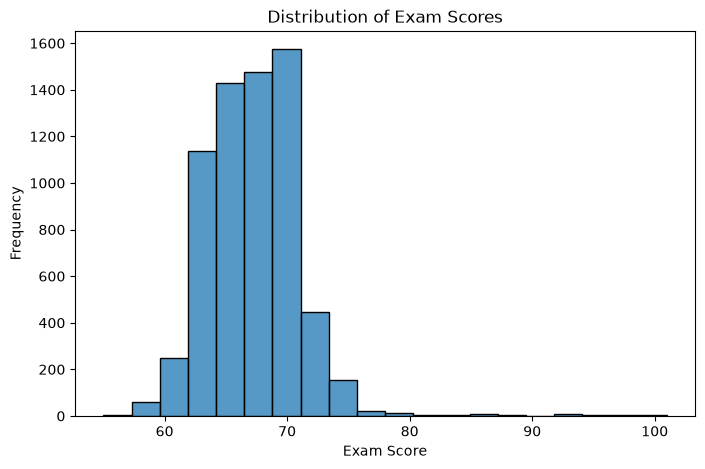

In [10]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="Exam_Score", bins=20)

plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Frequency")

plt.show()

In [11]:
# Feature 1: Study and attendance engagement
df["Study_Attendance_Index"] = (
    df["Hours_Studied"] * df["Attendance"] / 100
)

# Feature 2: Academic support
df["Academic_Support_Index"] = (
    df["Tutoring_Sessions"] + df["Previous_Scores"] / 100
)

# Feature 3: Self-created feature
df["Study_Efficiency"] = (
    df["Previous_Scores"] / (df["Hours_Studied"] + 1)
)

df[
    [
        "Study_Attendance_Index",
        "Academic_Support_Index",
        "Study_Efficiency"
    ]
].head()

,Study_Attendance_Index,Academic_Support_Index,Study_Efficiency
0,19.32,0.73,3.041667
1,12.16,2.59,2.950000
2,23.52,2.91,3.640000
3,25.81,1.98,3.266667
4,17.48,3.65,3.250000


In [12]:
X = df.drop(columns=["Exam_Score"])
y = df["Exam_Score"]

print("Features:", X.shape)
print("Target:", y.shape)



X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Features: (6607, 19)
Target: (6607,)
Training data: (5285, 19)
Testing data: (1322, 19)


In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numerical_columns
        ),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_columns
        )
    ]
)
   

print("Preprocessor created successfully!")
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)
linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Preprocessor created successfully!
Linear Regression model trained successfully!


In [14]:
y_pred = linear_model.predict(X_test)

print("Predictions:")
print(y_pred[:10])

Predictions:
[64.71401586 65.444395   70.7752992  65.47976128 66.64035721 66.87663163
 72.54270493 66.12462865 69.22029682 69.77544558]


In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse= np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Evaluation")
print("----------------------------")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

Linear Regression Evaluation
----------------------------
MAE: 0.6737559015581712
MSE: 3.609028596978614
RMSE: 1.8997443504268183
R² Score: 0.7446756213059301


In [16]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(results.head(10))

   Actual  Predicted
0      65  64.714016
1      65  65.444395
2      71  70.775299
3      64  65.479761
4      66  66.640357
5      66  66.876632
6      72  72.542705
7      66  66.124629
8      70  69.220297
9      70  69.775446


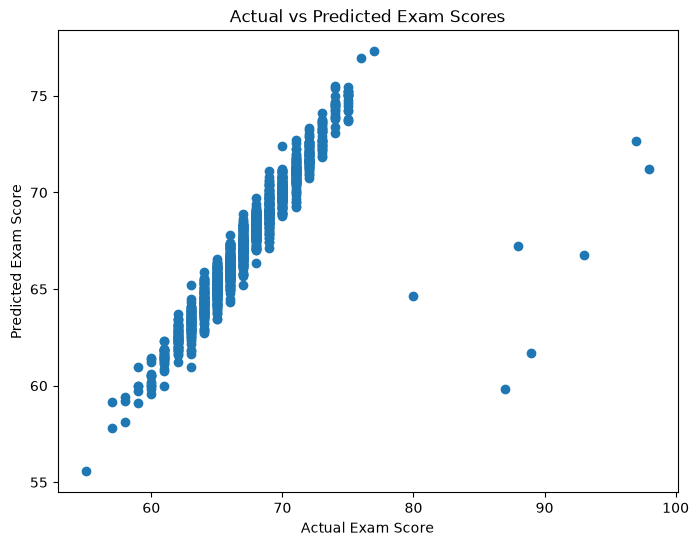

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs Predicted Exam Scores")
plt.show()

In [18]:
from sklearn.ensemble import RandomForestRegressor

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=100,
                random_state=42
            )
        )
    ]
)
random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [19]:
y_pred_rf = random_forest_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Evaluation")
print("-----------------------")
print("MAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest Evaluation
-----------------------
MAE : 1.1133131618759458
MSE : 4.730476550680787
RMSE: 2.174965873451992
R²  : 0.665337651455413


In [20]:
comparison = pd.DataFrame({
    "Model": ["linear", "Random Forest"],
    "MAE": [mae, mae_rf],
    "MSE": [mse, mse_rf],
    "RMSE": [rmse, rmse_rf],
    "R²": [r2, r2_rf]
})

display(comparison)

# Count which model performs better on each metric
linear_wins = 0
rf_wins = 0

if mae < mae_rf:
    linear_wins += 1
else:
    rf_wins += 1

if mse < mse_rf:
    linear_wins += 1
else:
    rf_wins += 1

if rmse < rmse_rf:
    linear_wins += 1
else:
    rf_wins += 1

if r2 > r2_rf:
    linear_wins += 1
else:
    rf_wins += 1

if rf_wins > linear_wins:
    winner = "Random Forest"
elif linear_wins > rf_wins:
    winner = "linear"
else:
    winner = "Tie"

print("\nModel Comparison Result")
print("-----------------------")
print("Linear Regression metric wins:", linear_wins)
print("Random Forest metric wins:", rf_wins)
print("Winner:", winner)

,Model,MAE,MSE,RMSE,R²
0,linear,0.673756,3.609029,1.899744,0.744676
1,Random Forest,1.113313,4.730477,2.174966,0.665338



Model Comparison Result
-----------------------
Linear Regression metric wins: 4
Random Forest metric wins: 0
Winner: linear


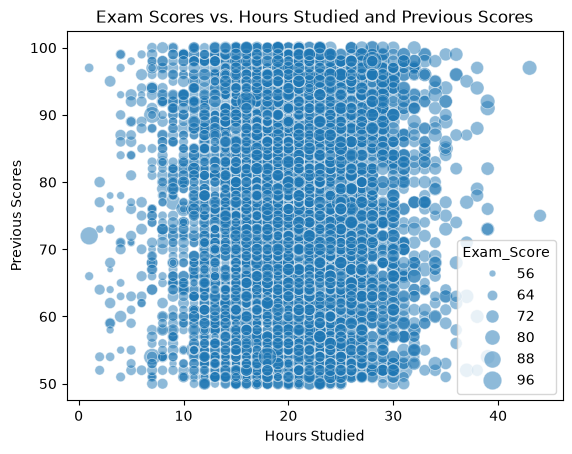

In [21]:
sns.scatterplot(data=df, x='Hours_Studied', y='Previous_Scores', size='Exam_Score', sizes=(20, 200), alpha=0.5)

plt.title('Exam Scores vs. Hours Studied and Previous Scores')

plt.xlabel('Hours Studied')

plt.ylabel('Previous Scores')

plt.show()

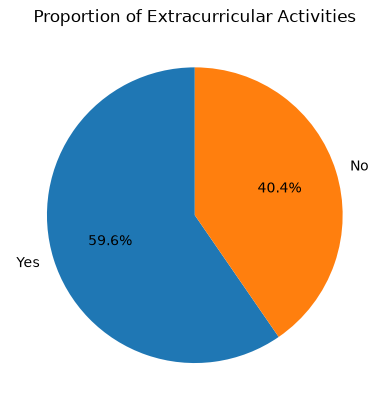

In [22]:
category_counts = df['Extracurricular_Activities'].value_counts()

plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', startangle=90)

plt.title('Proportion of Extracurricular Activities')

plt.show()

In [23]:

print(df.columns.tolist())
print(df.shape)

['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Gender', 'Exam_Score', 'Study_Attendance_Index', 'Academic_Support_Index', 'Study_Efficiency']
(6607, 20)


In [27]:
# Create a test student

student = pd.DataFrame({
    "Hours_Studied": [20],
    "Attendance": [90],
    "Parental_Involvement": ["High"],
    "Access_to_Resources": ["High"],
    "Extracurricular_Activities": ["Yes"],
    "Sleep_Hours": [7],
    "Previous_Scores": [80],
    "Motivation_Level": ["High"],
    "Internet_Access": ["Yes"],
    "Tutoring_Sessions": [2],
    "Family_Income": ["Medium"],
    "School_Type": ["Public"],
    "Peer_Influence": ["Positive"],
    "Physical_Activity": [3],
    "Learning_Disabilities": ["No"],
    "Gender": ["Female"]
})

# Create engineered features
student["Study_Attendance_Index"] = (
    student["Hours_Studied"] *
    student["Attendance"] / 100
)

student["Academic_Support_Index"] = (
    student["Tutoring_Sessions"] +
    student["Physical_Activity"] * 0.5
)

student["Study_Efficiency"] = (
    student["Hours_Studied"] /
    (student["Sleep_Hours"] + 1)
)



student1 = student.copy()

student2 = student.copy()
student2["Hours_Studied"] = 40
student2["Attendance"] = 100
student2["Previous_Scores"] = 100

student3 = student.copy()
student3["Hours_Studied"] = 5
student3["Attendance"] = 60
student3["Previous_Scores"] = 50
display(student1)
display(student2)
display(student3)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Gender,Study_Attendance_Index,Academic_Support_Index,Study_Efficiency
0,20,90,High,High,Yes,7,80,High,Yes,2,Medium,Public,Positive,3,No,Female,18.0,3.5,2.5


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Gender,Study_Attendance_Index,Academic_Support_Index,Study_Efficiency
0,40,100,High,High,Yes,7,100,High,Yes,2,Medium,Public,Positive,3,No,Female,18.0,3.5,2.5


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Gender,Study_Attendance_Index,Academic_Support_Index,Study_Efficiency
0,5,60,High,High,Yes,7,50,High,Yes,2,Medium,Public,Positive,3,No,Female,18.0,3.5,2.5


In [28]:
print("Student 1")
print("Linear Regression:", round(linear_model.predict(student1)[0], 2))
print("Random Forest:", round(random_forest_model.predict(student1)[0], 2))

print("\nStudent 2")
print("Linear Regression:", round(linear_model.predict(student2)[0], 2))
print("Random Forest:", round(random_forest_model.predict(student2)[0], 2))

print("\nStudent 3")
print("Linear Regression:", round(linear_model.predict(student3)[0], 2))
print("Random Forest:", round(random_forest_model.predict(student3)[0], 2))

Student 1
Linear Regression: 73.12
Random Forest: 72.73

Student 2
Linear Regression: 81.95
Random Forest: 77.96

Student 3
Linear Regression: 61.26
Random Forest: 61.22
